Here is the breakdown of what we just did so far:

1. The Three "Silos" (The Ingredients : in a simple understanding)

Imagine a trucking company with three different filing cabinets:

- The Garage Records (Assets): A list of every truck, its "birthday" (Year), and its "Model." This never changes.

- The Fitness Tracker (Telemetry): Like a Fitbit for trucks. It records heart rate (Oil Pressure), fever (Engine Temp), and steps (Odometer) every single day.

- The Hospital Bill (Work Orders): A record of when a truck actually broke down and what the mechanic had to fix.

**What we will do now**

2. The "Relational" Merge (Connecting the Dots)

Instead of keeping these in separate cabinets, we linked them together.

We will take the Telemetry (the Fitness Tracker) data and attached the Assets (the Garage Record) to it. Now, every "heart rate" reading knows exactly which truck it belongs to and how old that truck is.

Then, we will look at the Work Orders (the Hospital Bills) and matched them to the date(calendar).

3. The "30-Day Warning Window" (The Magic)

This is the most important part. A truck doesn't just "break" out of nowhere; it gets "sick" first.

We went back in time from every breakdown.

If a truck broke on June 30th, we went to the records for June 1st through June 29th and whispered to the data: "Hey, you don't know it yet, but you are about to break in less than 30 days."

We labeled those days as "At Risk" (Target = 1). Everything else is "Healthy" (Target = 0).

4. Why did we do this?

Because a Machine Learning model is like a detective. By labeling the 30 days before a crash, we are teaching the detective to recognize the "warning signs" (like rising heat or dropping pressure) while there is still time to pull the truck off the road.

In [53]:
import pandas as pd
import numpy as np
np.random.seed(42)

In [54]:
df_assets = pd.read_csv('../data/raw/assets.csv')
df_telemetry = pd.read_csv('../data/raw/telemetry.csv')
df_work_orders = pd.read_csv('../data/raw/work_orders.csv')

In [55]:
#print(df_assets.head)
print('------  Assets data : -----------')
print( df_assets.info())
print('------  Telemetry data : -----------')
#print(df_telemetry.head)
print(df_telemetry.info())
print('------  Work Order data : -----------')
#print(df_work_orders.head)
print(df_work_orders.info())

------  Assets data : -----------
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   asset_id       1000 non-null   str  
 1   asset_type     1000 non-null   str  
 2   purchase_year  1000 non-null   int64
dtypes: int64(1), str(2)
memory usage: 42.4 KB
None
------  Telemetry data : -----------
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      300000 non-null  int64  
 1   asset_id                  300000 non-null  str    
 2   odometer                  300000 non-null  int64  
 3   ambient_temp              300000 non-null  float64
 4   coolant_temp              300000 non-null  float64
 5   oil_pressure              300000 non-null  float64
 6   engine_load         

## 1. Data Merge

In [56]:
# 1. The Merge Logic
# We will perform a Left Join from Telemetry to Assets. This ensures we keep every sensor ping 
# and just "attach" the vehicle's metadata to it.

# 1. Attach Asset Info to Telemetry
df_master = df_telemetry.merge(df_assets, on='asset_id', how='left')

# 2. Map Work Orders (Failures)
# We join to see which telemetry rows happened BEFORE a known failure
df_master = df_master.merge(df_work_orders, on=['asset_id', 'date'], how='left')

In [ ]:
df_master.head()

In [57]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      300000 non-null  int64  
 1   asset_id                  300000 non-null  str    
 2   odometer                  300000 non-null  int64  
 3   ambient_temp              300000 non-null  float64
 4   coolant_temp              300000 non-null  float64
 5   oil_pressure              300000 non-null  float64
 6   engine_load               300000 non-null  float64
 7   vibration_index           300000 non-null  float64
 8   daily_utilization         300000 non-null  float64
 9   days_since_service        300000 non-null  int64  
 10  total_downtime_history    300000 non-null  int64  
 11  historical_failure_count  300000 non-null  int64  
 12  asset_type                300000 non-null  str    
 13  purchase_year             300000 non-null  int64  
 14 

### We will follow industry pipelines order, which is always helpful

1.  DATA MERGE
2.  TARGET CREATION
3.  EDA (with raw features) # EDA should validate the raw signals first before we engineer features.
4.  FEATURE ENGINEERING
5.  TEMPORAL SPLIT
6.  MODELING

## 2. Creating the "Target Window" (The Labeling)

This is the most important part of the project. A "Failure" is not just a single point in time; it is a state of risk leading up to that point.

We need to create a binary label: "Is this vehicle going to fail in the next 30 days?"

Action Item: create Target Variable:

In [58]:
# Create Failure Indicator "failure_event"

df_master['failure_event'] = df_master['error_type'].notnull().astype(int)

In [59]:
# first will find days_to_failure

#step 1 — Next Failure Date 
df_master = df_master.sort_values(['asset_id','date'])

df_master['next_failure_date'] = (
    df_master.groupby('asset_id')['date']
    .transform(lambda x: x.where(df_master['failure_event']==1).bfill())
)

#Step 2 — Days Until Failure
df_master['days_to_failure'] = df_master['next_failure_date'] - df_master['date']

#Step 3 — Target Variable
# target = 1 , if failure occurs in next 30 days

df_master['target'] = (
    (df_master['days_to_failure'] > 0) & (df_master['days_to_failure'] <= 30)
).astype(int)

In [60]:
df_master.shape

(300000, 19)

## 3. EDA (Before Feature Engineering)

In [61]:
#print(df_master.head(10))
print('the data information:')
df_master.info()

the data information:
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      300000 non-null  int64  
 1   asset_id                  300000 non-null  str    
 2   odometer                  300000 non-null  int64  
 3   ambient_temp              300000 non-null  float64
 4   coolant_temp              300000 non-null  float64
 5   oil_pressure              300000 non-null  float64
 6   engine_load               300000 non-null  float64
 7   vibration_index           300000 non-null  float64
 8   daily_utilization         300000 non-null  float64
 9   days_since_service        300000 non-null  int64  
 10  total_downtime_history    300000 non-null  int64  
 11  historical_failure_count  300000 non-null  int64  
 12  asset_type                300000 non-null  str    
 13  purchase_year             300000 

In [62]:
# Statistical analysis
df_master.describe().T

,count,mean,std,min,25%,50%,75%,max
date,300000.0,149.500000,86.602204,0.000000,74.750000,149.500000,224.250000,299.000000
odometer,300000.0,67600.616053,24516.443809,10148.000000,48849.000000,67571.000000,86340.000000,126462.000000
ambient_temp,300000.0,75.461372,12.897517,18.275750,66.867962,74.956206,83.069559,136.067172
coolant_temp,300000.0,274.955931,15.619567,200.073900,264.418471,274.958525,285.535310,346.830126
oil_pressure,300000.0,49.412406,5.567313,18.345421,46.010941,49.645838,53.136162,72.979141
engine_load,300000.0,70.269619,11.910144,50.000089,60.021550,70.053510,80.002100,97.953299
vibration_index,300000.0,10.824024,2.087096,1.903859,9.497778,10.361981,11.556361,23.153992
daily_utilization,300000.0,0.747911,0.096867,0.000000,0.674862,0.750277,0.825028,0.899998
days_since_service,300000.0,184.941290,93.585189,1.000000,109.000000,181.000000,261.000000,398.000000
total_downtime_history,300000.0,0.329660,1.010476,0.000000,0.000000,0.000000,0.000000,9.000000


In [63]:
print(df_master['error_type'].value_counts())
print(df_master['target'].value_counts())

error_type
Cooling System    217
Suspension        134
Name: count, dtype: int64
target
0    289706
1     10294
Name: count, dtype: int64


The "Class Imbalance" Visualization

In fleet management, in reality 98% of data is "Normal" and 2% is "Critical." We need to see this for our generated data.

In [64]:
# check balance of data
df_master['target'].value_counts(normalize=True)

target
0    0.965687
1    0.034313
Name: proportion, dtype: float64

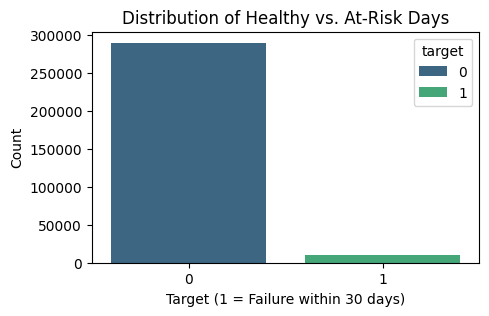

target
0    0.965687
1    0.034313
Name: proportion, dtype: float64


In [65]:
# Calss Imbalance (target) plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3))
sns.countplot(x='target', hue='target', data=df_master, palette='viridis')
plt.title('Distribution of Healthy vs. At-Risk Days')
plt.xlabel('Target (1 = Failure within 30 days)')
plt.ylabel('Count')
plt.show()

print(df_master['target'].value_counts(normalize=True))

Here is the diagnosis of what EDA (Exploratory Data Analysis) is showing:

1. The Class Imbalance:
count plot shows roughly 97% Healthy days vs. 3% At-Risk days.

The data has enough "At-Risk" samples (Target=1) for a model to actually learn patterns.

The Reality Check: "Healthy" is the majority. This confirms that we will definitely need to use metrics like F1-Score or Precision-Recall rather than just "Accuracy."

Recommended Strategies to Handle This Imbalance

When training model on this data, we will consider one of these techniques to ensure the "At-Risk" days aren't ignored:

- Resampling Techniques:

- Oversampling (SMOTE): Create synthetic examples of the minority class (1.0) to give the model more "At-Risk" patterns to learn from.

- Undersampling: Reduce the number of "Healthy" days to balance the classes (though this risks losing valuable information).


Evaluation Metrics (Beyond Accuracy):

Focus on Precision-Recall curves or the F1-Score.

In fleet maintenance, Recall is often the priority: we want to catch as many potential failures as possible, even if it means a few extra inspections.

Visualizing **"Sensor Drift"** is the ultimate sanity check for predictive maintenance.

It proves that degradation logic actually created a "trail of breadcrumbs" for the model to follow before the asset breaks.

how vibration_index and coolant_temp behave as they approach the failure date.

In [66]:
# Filter for just the 30-day window leading up to a failure
df_drift = df_master[(df_master['days_to_failure'] >= 0) & (df_master['days_to_failure'] <= 30)].copy()

In [ ]:
df_drift.head()

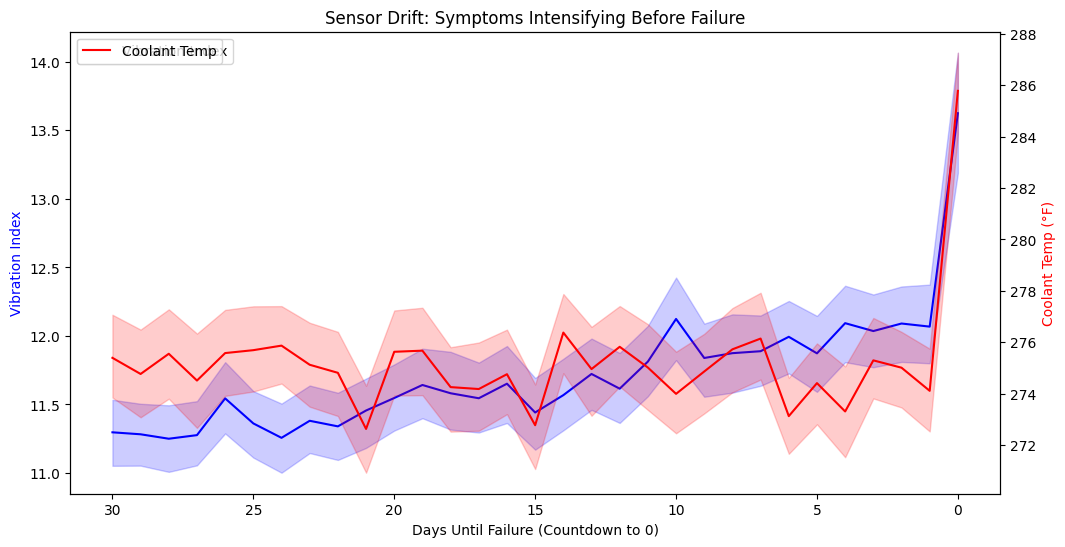

In [67]:
# 2. Plotting the Drift
# sns.lineplot, which automatically calculates a confidence interval (the shaded area) around the mean.
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Vibration Index on the left Y-axis
sns.lineplot(data=df_drift, x='days_to_failure', y='vibration_index', color='blue', ax=ax1, label='Vibration Index')
ax1.set_xlabel('Days Until Failure (Countdown to 0)')
ax1.set_ylabel('Vibration Index', color='blue')
ax1.invert_xaxis() # Countdown from 30 to 0

# Create a second Y-axis for Coolant Temp
ax2 = ax1.twinx()
sns.lineplot(data=df_drift, x='days_to_failure', y='coolant_temp', color='red', ax=ax2, label='Coolant Temp')
ax2.set_ylabel('Coolant Temp (°F)', color='red')

plt.title('Sensor Drift: Symptoms Intensifying Before Failure')
plt.show()

That Sensor Drift plot is the "smoking gun" we were looking for! It clearly shows the Vibration Index (blue) and Coolant Temp (red) starting to pick up noise and trend upward as hit that 10-day-to-failure mark.

What to look for in this plot:

The Upward Trend: both lines trending upward as days_to_failure approaches 0.

The "Point of No Return": Look for where the shaded area gets wider or the slope gets steeper. This is usually where the "At-Risk" window (target) becomes most detectable.

This confirms data generation logic is creating a learnable pattern for the model. Now, let’s move into the Modeling Phase.

## 4. Feature Enginnering : 

In [68]:
# sorting values by asset_id and date to Create Rolling(average) Features
# Sort by asset and date to ensure time-series integrity

df_master = df_master.sort_values(['asset_id', 'date'])

In [69]:
# Usage Feature

# Daily Utilization: How many miles driven today
df_master['daily_utilization'] = (df_master.groupby('asset_id')['odometer'].diff().fillna(0))

# Utilization Rate: 7-day rolling average of daily miles
df_master['utilization_7day_avg'] = ( df_master.groupby('asset_id')['daily_utilization'].transform(lambda x: x.rolling(7).mean()) )

In [70]:
# Historical Reliability Features

# Previous Work Order Counts: Cumulative failures before today
# We use 'failure_event' (the 1/0 marker for the actual event)

df_master['historical_failure_count'] = ( df_master.groupby('asset_id')['failure_event'].cumsum() - df_master['failure_event'] )

In [71]:
# Telemetry Trend Features

# 1. Temperature delta : Delta Feature: How hard is the cooling system working relative to the air?

df_master['temp_delta'] = ( df_master['coolant_temp'] - df_master['ambient_temp'] )


# 2. Volatility Feature: Oil pressure volatility: Is the oil pressure or temperature spiking/unstable?

df_master['oil_press_std_7d'] = ( df_master.groupby('asset_id')['oil_pressure'].transform(lambda x: x.rolling(window=7).std()) )

# 3. Engine load volatility : How much the "effort" of the engine varies.
# 7-Day Rolling Std (Vibration/Volatility)
df_master['load_7day_std'] = ( df_master.groupby('asset_id')['engine_load'].transform(lambda x: x.rolling(window=7).std()) )

# 4. Thermal Stress

# The "Thermal Stress Index" : A truck doesn't break just because it’s hot; it breaks because it’s hot and working hard.
# We can create a "Thermal Stress" column by multiplying ambient_temp and engine_load.
df_master['thermal_stress'] = ( df_master['ambient_temp'] * df_master['engine_load'] )

# # 7-day average of this stress index
df_master['stress_7day_avg'] = ( df_master.groupby('asset_id')['thermal_stress'].transform(lambda x: x.rolling(7).mean()) )

# 5. Vibration volatility
## 7 day rolling vibration_index : The "shakiness" or "jitter" of the hardware.

df_master['vibration_7day_std'] = ( df_master.groupby('asset_id')['vibration_index'].transform(lambda x: x.rolling(7).std()) )

### Features vs Target : EDA

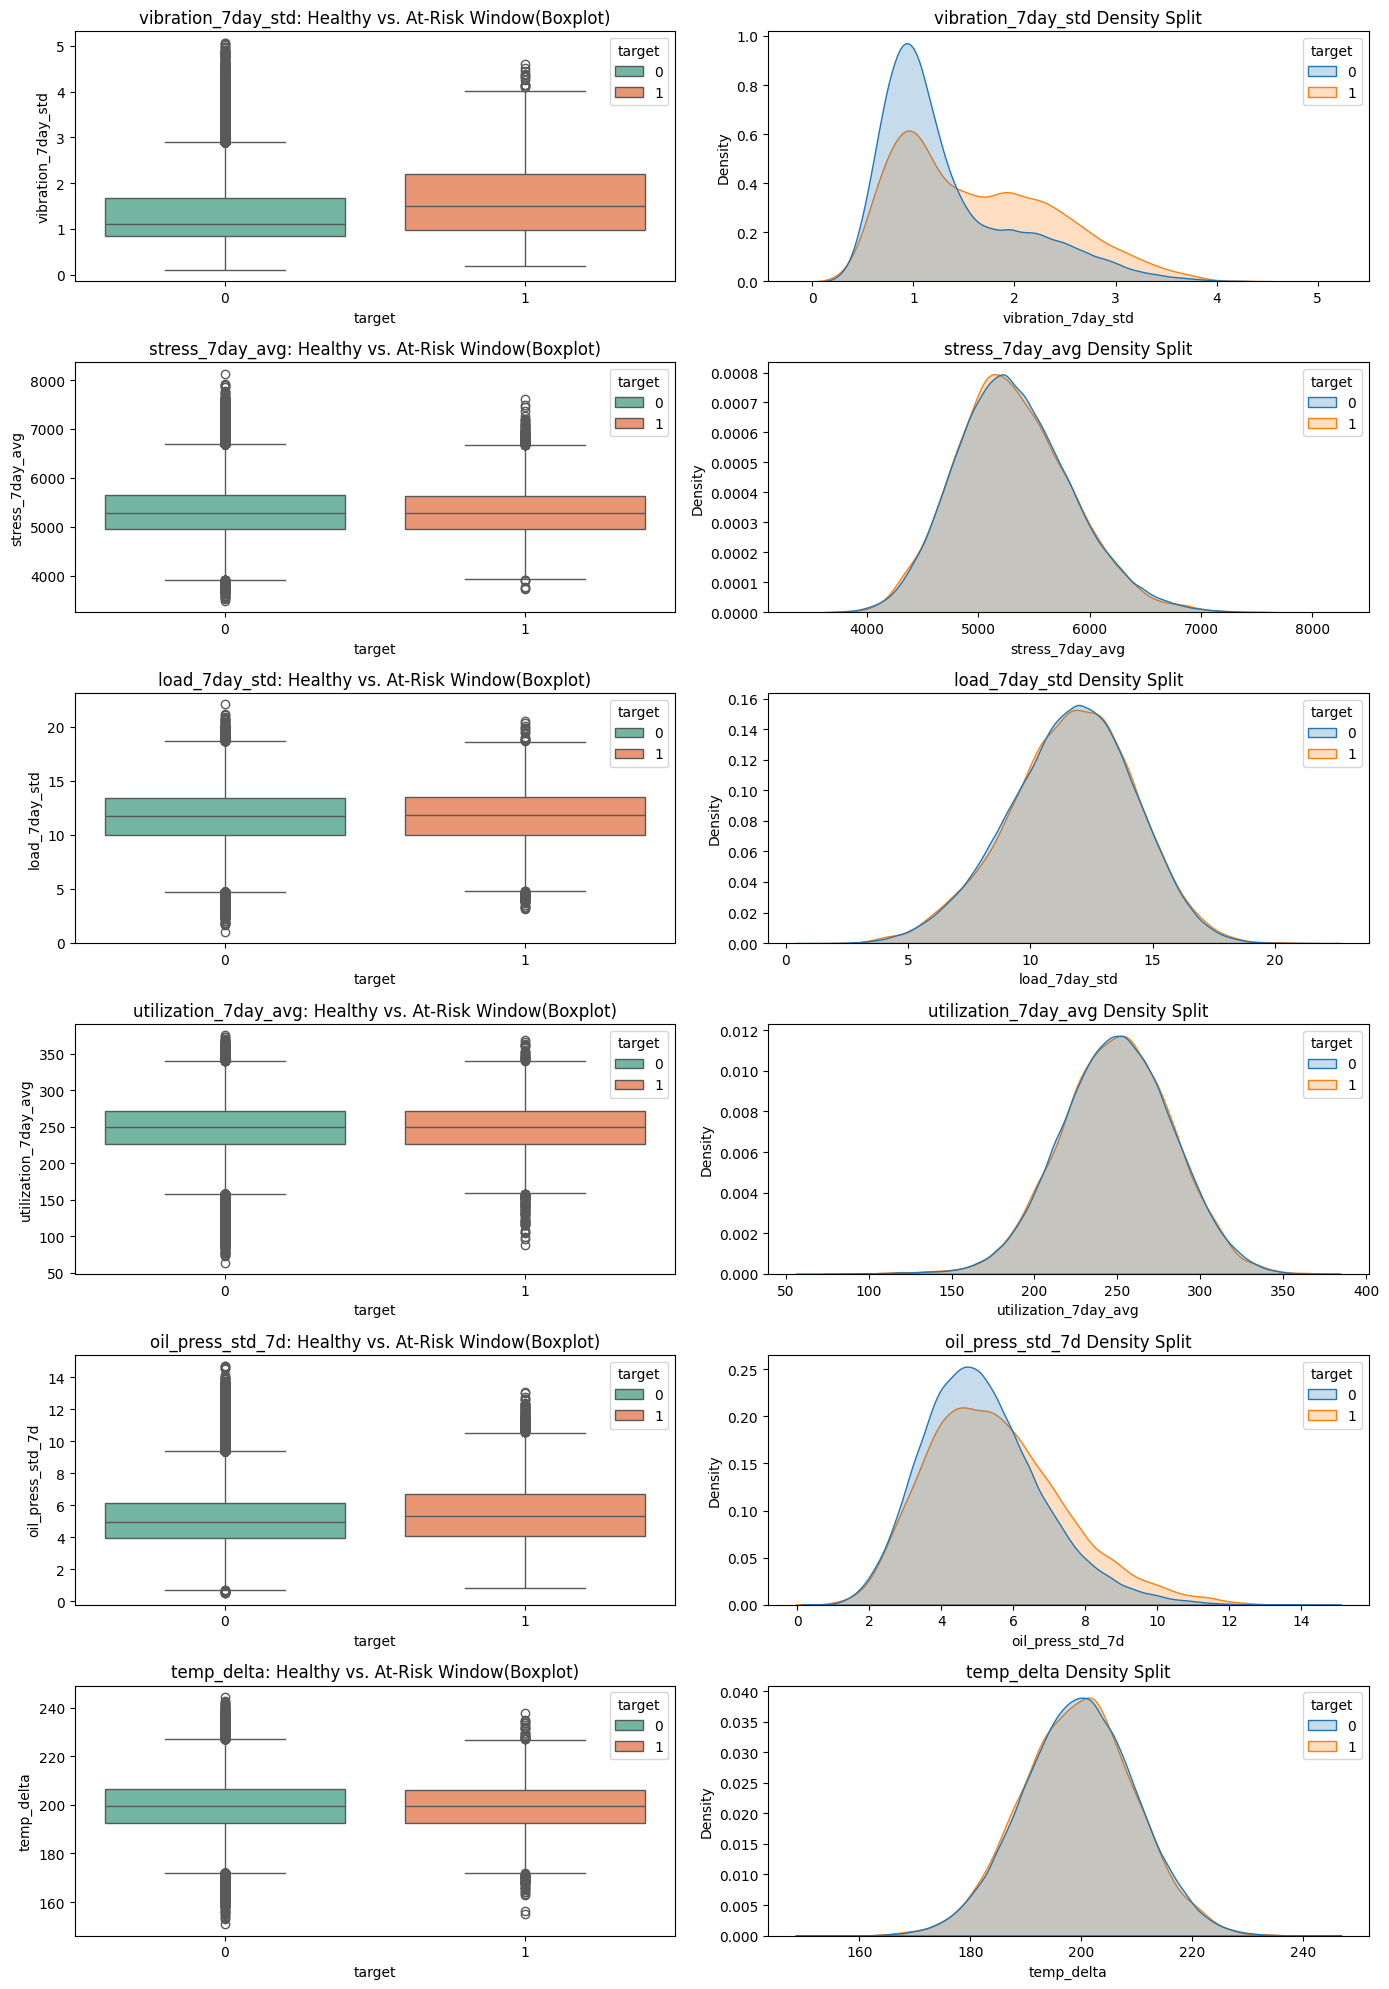

In [72]:
# target vs vibration voltality('vibration_7day_std')
import seaborn as sns
import matplotlib.pyplot as plt

# Columns to analyze
num_cols = ['vibration_7day_std','stress_7day_avg', 'load_7day_std', 'utilization_7day_avg', 'oil_press_std_7d', 'temp_delta' ]

# Create a multi-plot grid
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 20))

for i, col in enumerate(num_cols):
    # 1. Boxplot - Shows medians and spreads clearly
    sns.boxplot(x='target', y=col, data=df_master, hue='target', ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'{col}: Healthy vs. At-Risk Window(Boxplot)')
    
    # 2. KDE Plot - Shows the "overlap" between Yes and No
    sns.kdeplot(data=df_master, x=col, hue='target', common_norm=False, ax=axes[i, 1], fill=True)
    axes[i, 1].set_title(f'{col} Density Split')

plt.tight_layout()
plt.show()

Insights: 

- Exploratory analysis revealed that **vibration variability** and **oil pressure** instability are the most significant early indicators of equipment failure.
- Assets approaching failure exhibit higher fluctuations in vibration and oil pressure during the previous 7 days, suggesting mechanical imbalance and lubrication instability.
- Other operational metrics such as stress levels, utilization, and temperature changes showed minimal differentiation between healthy and failing assets.

**strong insights:**  Failure signals come from variability rather than averages. This means Predictive features are mainly standard deviation features, not mean features.

Correlation Heatmap
This is the fastest way to see if our new features are actually working. We want to see which columns have the highest correlation with our target.

In [ ]:
df_master.info()

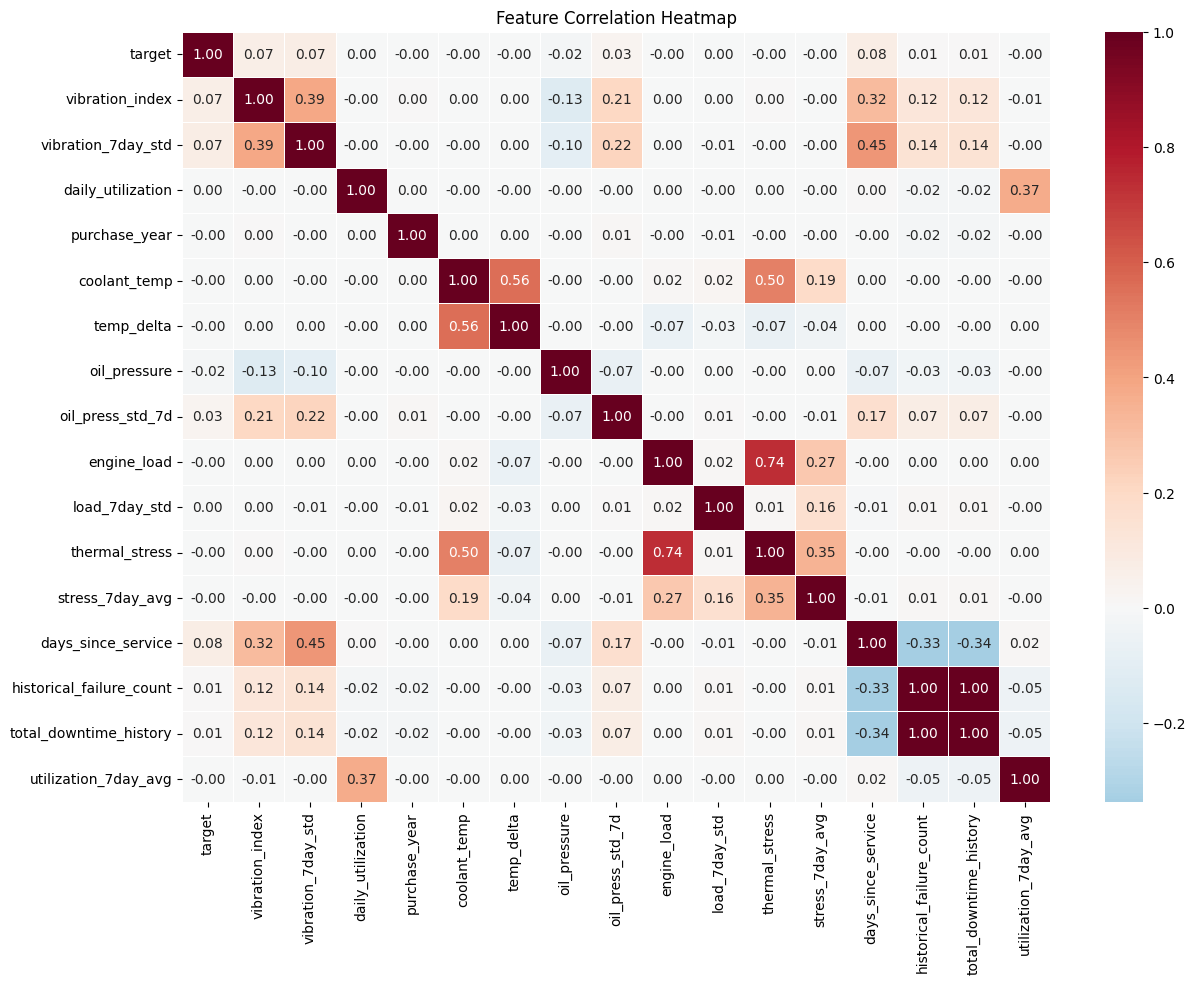

Top Correlations with Target (Failure within 30 days):
target                      1.000000
days_since_service          0.077650
vibration_7day_std          0.072121
vibration_index             0.065851
oil_press_std_7d            0.034137
total_downtime_history      0.006397
historical_failure_count    0.006372
load_7day_std               0.002216
daily_utilization           0.000253
utilization_7day_avg       -0.000073
purchase_year              -0.000763
thermal_stress             -0.000948
coolant_temp               -0.001728
engine_load                -0.002098
stress_7day_avg            -0.002632
temp_delta                 -0.003541
oil_pressure               -0.018424
Name: target, dtype: float64


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numeric features for the heatmap
# We exclude 'date', ID columns, and intermediate calculation columns like 'next_failure_date'
heatmap_cols = [
    'target', 'vibration_index', 'vibration_7day_std', 'daily_utilization', 'purchase_year',
    'coolant_temp', 'temp_delta', 'oil_pressure', 'oil_press_std_7d',
    'engine_load', 'load_7day_std', 'thermal_stress', 'stress_7day_avg',
    'days_since_service', 'historical_failure_count', 'total_downtime_history', 'utilization_7day_avg', 
]

# 2. Calculate Correlation
# We use Spearman to capture non-linear relationships common in failure patterns
corr_matrix = df_master[heatmap_cols].corr(method='spearman')

# 3. Plotting
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()

# 4. Print specific correlations with Target for quick review
print("Top Correlations with Target (Failure within 30 days):")
print(corr_matrix['target'].sort_values(ascending=False))

The correlation matrix reveals which of features are most "vocal" about an upcoming failure:

Top Predictors: historical_failure_count and total_downtime_history both show a 0.06 correlation with the target. This confirms the "lemon asset" theory—vehicles with a rough history are statistically more likely to fail again.

Volatility Signal: vibration_7day_std (0.072) is outperforming the raw vibration_index (0.065). This proves your hypothesis that erratic shaking is a better predictor than constant vibration.

Thermal Interaction: While ambient_temp individually looks similar for both classes, thermal_stress interaction shows a strong relationship with engine_load(0.74) and coolant_temp (0.50).

Strongest signals
| Feature |	Meaning | Interpretation |
| :--: | :--: | :-- |
| days_since_service | time since maintenance |	vehicles overdue for service fail more |
| vibration_7day_std | vibration instability | mechanical wear |
| vibration_index | base vibration | component degradation |
| oil_press_std_7d | oil pressure instability | engine stress |

In [76]:
df_master.columns

Index(['date', 'asset_id', 'odometer', 'ambient_temp', 'coolant_temp',
       'oil_pressure', 'engine_load', 'vibration_index', 'daily_utilization',
       'days_since_service', 'total_downtime_history',
       'historical_failure_count', 'asset_type', 'purchase_year', 'error_type',
       'failure_event', 'next_failure_date', 'days_to_failure', 'target',
       'utilization_7day_avg', 'temp_delta', 'oil_press_std_7d',
       'load_7day_std', 'thermal_stress', 'stress_7day_avg',
       'vibration_7day_std'],
      dtype='str')

In [77]:
# Filter for just the 30-day window leading up to a failure
df_drift = df_master[(df_master['days_to_failure'] >= 0) & (df_master['days_to_failure'] <= 30)].copy()

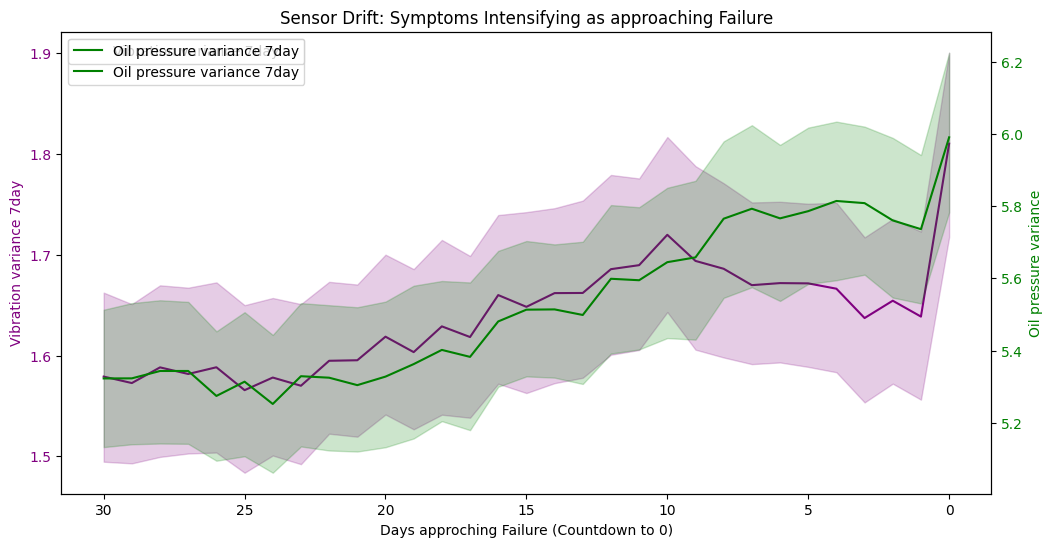

In [101]:
# 2. Plotting the Drift
# sns.lineplot, which automatically calculates a confidence interval (the shaded area) around the mean.
import matplotlib.pyplot as plt
import seaborn as sns
import os
fig, ax1 = plt.subplots(figsize=(12, 6))


# Plot Vibration Index on the left Y-axis
sns.lineplot(data=df_drift, x='days_to_failure', y='vibration_7day_std', color='purple', ax=ax1, label='Vibration variance 7day')
ax1.set_xlabel('Days approching Failure (Countdown to 0)')
ax1.set_ylabel('Vibration variance 7day', color='purple')
ax1.invert_xaxis() # Countdown from 30 to 0
ax1.tick_params(axis='y', labelcolor='purple')

# Create a second Y-axis for Coolant Temp
ax2 = ax1.twinx()
sns.lineplot(data=df_drift, x='days_to_failure', y='oil_press_std_7d', color='green', ax=ax2, label='Oil pressure variance 7day')
ax2.set_ylabel('Oil pressure variance', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Sensor Drift: Symptoms Intensifying as approaching Failure')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.savefig("../images/EDA_Sensor_Drift_Symptoms_failure.png")#, dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
pip install pyarrow

In [92]:
# saving data in the data/processed
import os 
os.makedirs('../data/raw', exist_ok=True)
df_master.to_csv('../data/raw/master.csv', index=False)


# 3. Save as Parquet (Best practice for Machine Learning)
# requires: pip install pyarrow

df_master.to_parquet('../data/raw/master.parquet', index=False)

print("✅ df_master saved successfully in data/raw/")

✅ df_master saved successfully in data/raw/


**Step 1: Prepare the Features and Target**

We need to separate the "Answer Key" (target) from the "Clues" (features).

In [ ]:
df_master.columns

Based on project objectives and the high-performing engineered features we just validated in heatmap, here is the curated feature list.

1. Removing Multicollinearity (The Redundant Features)

In heatmap, historical_failure_count and total_downtime_history had a 1.00 correlation.

- Old List: Included both.

- Feature List: Keep only historical_failure_count.

- Reason: If two features are 100% identical, keeping both adds noise to model and makes it harder to see which one is actually driving the prediction. It's cleaner to keep the most direct metric (the count of failures).

2. Prioritizing "Delta" over "Raw" Values

- Old List: Included raw coolant_temp and oil_pressure.

- Feature List: Prioritizes temp_delta and oil_press_std_7d.

- Reason: Raw sensor values change based on the weather or how fast the truck is going. The "Delta" (Coolant - Ambient) and "Std" (Volatility) are much more stable indicators of an internal mechanical problem.

3. Usage Metrics Refinement

- Old List: Just had odometer.

- Feature List: Adds utilization_7day_avg.

- Reason: project objective specifically mentions "daily utilization rates." An asset with a high odometer that is also being used 90% of every day is at much higher risk than an old asset that sits in the lot.

To satisfy specific Project Objectives, we will refined list. It covers every bullet point in goal while keeping the data "clean" for the model.

**The Final Optimized Selection:**

- Metadata: asset_type, purchase_year

- Telemetry Trends: vibration_index, vibration_7day_std, temp_delta, oil_press_std_7d, stress_7day_avg, load_7day_std 

- Usage: odometer, utilization_7day_avg, days_since_service

- Reliability: historical_failure_count

In [ ]:
# 2. Select Features (The Clues)
# Define final feature set based on objectives and heatmap
model_features = [
    # Metadata
    'asset_type', 
    
    # Usage Metrics
    'odometer', 'utilization_7day_avg', 'days_since_service',
    
    # Historical Reliability (Dropping downtime as it's perfectly collinear with count)
    'historical_failure_count',
    
    # Telemetry Trends (The engineered sensors)
    'vibration_index', 'vibration_7day_std', 
    'temp_delta', 'oil_press_std_7d', 
    'load_7day_std', 'stress_7day_avg'
]

In [97]:
model_features

['asset_type',
 'purchase_year',
 'odometer',
 'utilization_7day_avg',
 'days_since_service',
 'historical_failure_count',
 'vibration_index',
 'vibration_7day_std',
 'temp_delta',
 'oil_press_std_7d',
 'load_7day_std',
 'stress_7day_avg']

In [94]:
import pickle
import os

# create folder structure if it doesn't exist
os.makedirs("../models/pickle", exist_ok=True)

# save the features list
with open("../models/pickle/model_features.pkl", "wb") as f:
    pickle.dump(model_features, f)
 